In [14]:
from IPython import get_ipython
from IPython.display import display
# %%
from google.colab import drive


In [15]:
import pandas as pd

file_path = '/content/diabetes_prediction_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [16]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# *Diabetes Prediction System*

In [17]:
df2=df.copy()

In [18]:
df2.shape

(100000, 9)

# **Graphical Representation of Data in the Dataset**

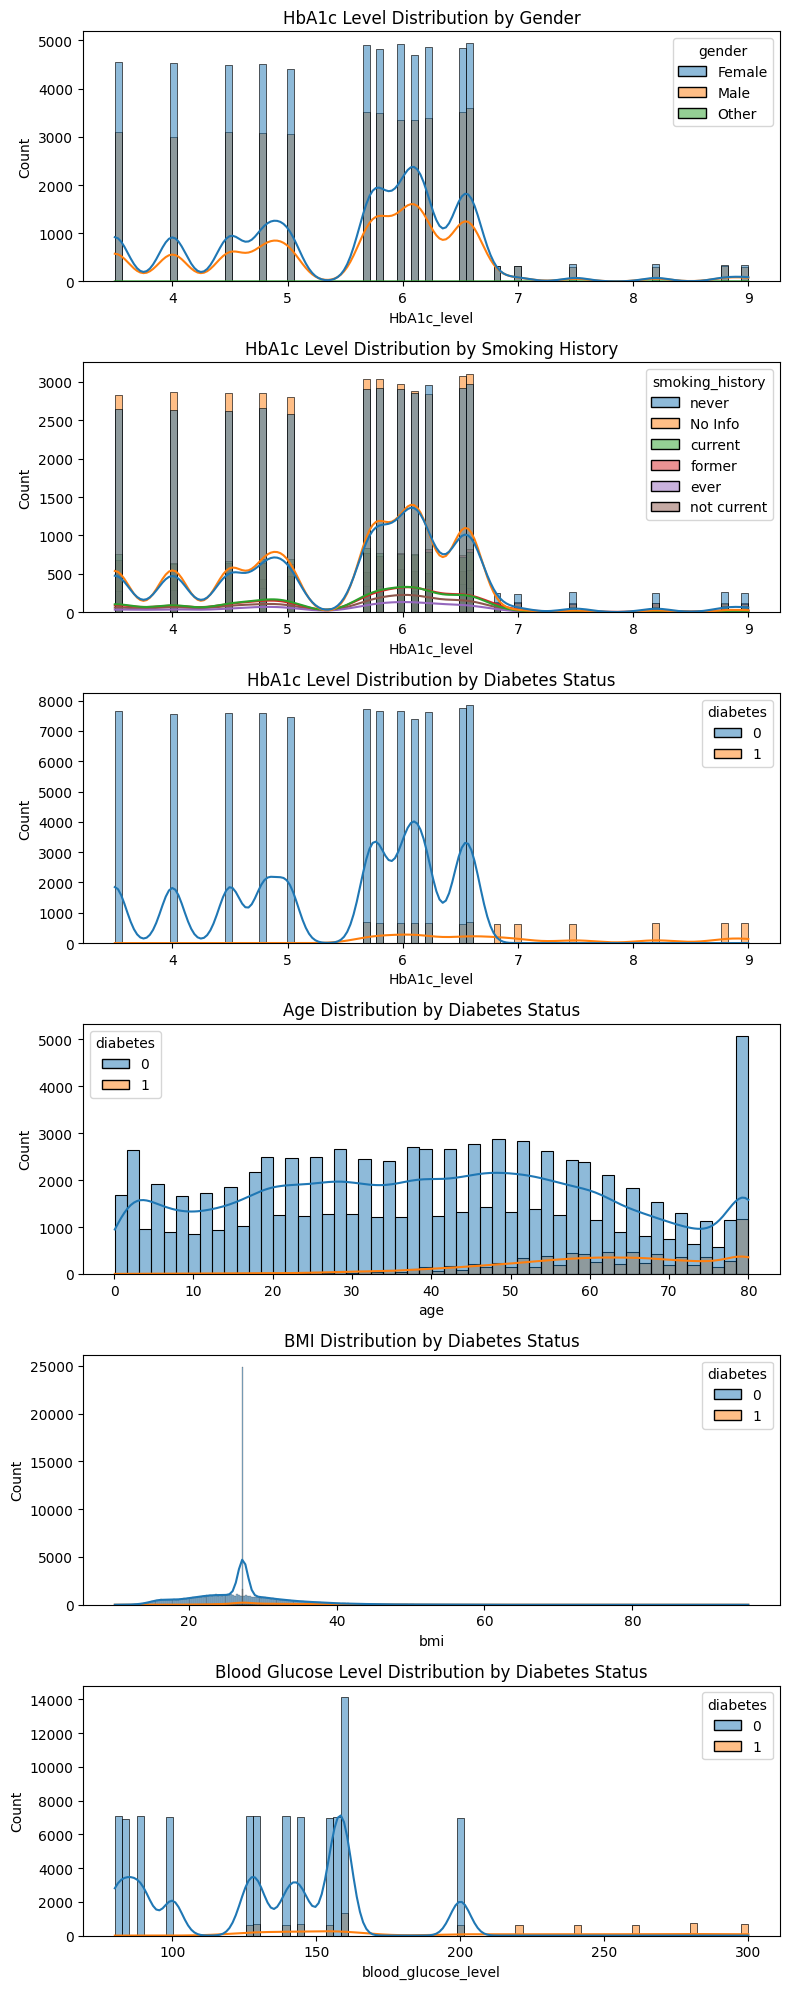

In [19]:

plt.figure(figsize=(8, 20))  # Increased height for 6 subplots

# 6 rows, 1 column layout
plt.subplot(6, 1, 1)
sns.histplot(df2, x='HbA1c_level', hue='gender', kde=True)
plt.title('HbA1c Level Distribution by Gender')

plt.subplot(6, 1, 2)
sns.histplot(df2, x='HbA1c_level', hue='smoking_history', kde=True)
plt.title('HbA1c Level Distribution by Smoking History')

plt.subplot(6, 1, 3)
sns.histplot(df2, x='HbA1c_level', hue='diabetes', kde=True)
plt.title('HbA1c Level Distribution by Diabetes Status')

plt.subplot(6, 1, 4)
sns.histplot(df2, x='age', hue='diabetes', kde=True)
plt.title('Age Distribution by Diabetes Status')

plt.subplot(6, 1, 5)
sns.histplot(df2, x='bmi', hue='diabetes', kde=True)
plt.title('BMI Distribution by Diabetes Status')

plt.subplot(6, 1, 6)
sns.histplot(df2, x='blood_glucose_level', hue='diabetes', kde=True)
plt.title('Blood Glucose Level Distribution by Diabetes Status')

plt.tight_layout()
plt.show()


# Exploratory Data Analysis (EDA) Preprossesing:

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Shape of Dataset: (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male

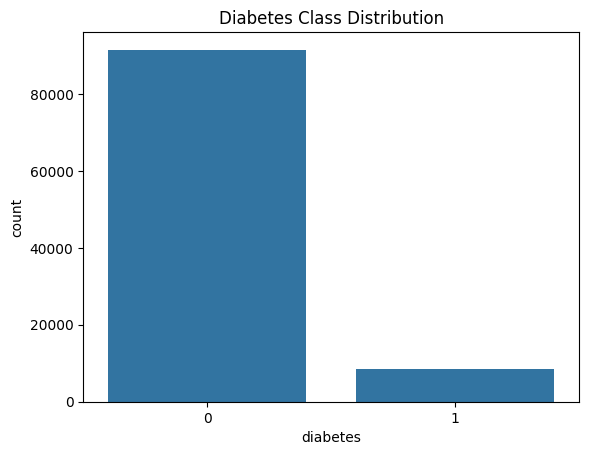

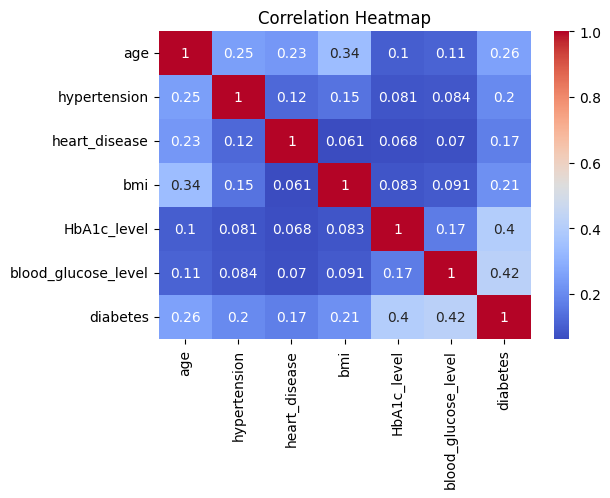

In [20]:

# 1. Basic Info
print("Dataset Info:")
df2.info()
print("\n")

# 2. Shape and First 5 Rows
print("Shape of Dataset:", df.shape)
print(df2.head(), "\n")

# 3. Null Values
print("Missing Values:")
print(df2.isnull().sum(), "\n")

# 4. Summary Stats (Numerical)
print("Summary Statistics:")
print(df2.describe(), "\n")

# 5. Unique Values in Key Categorical Columns
cat_cols = ['gender', 'smoking_history', 'diabetes']
for col in cat_cols:
    print(f"Unique values in '{col}':", df[col].unique())

# 6. Target Distribution (Diabetes)
sns.countplot(data=df, x='diabetes')
plt.title("Diabetes Class Distribution")
plt.show()

# 7. Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Logistic Regression

Accuracy: 0.95865

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.86      0.61      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



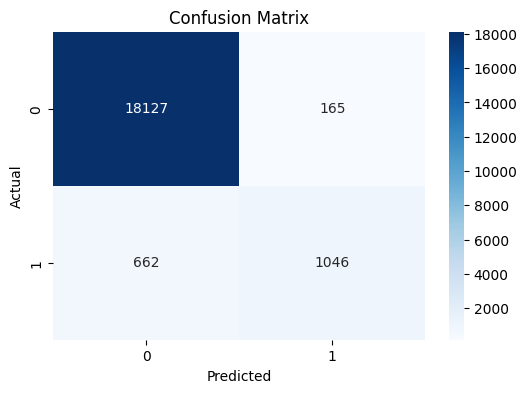

In [21]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
df2 = df.copy()
# Encode categorical columns
le = LabelEncoder()
df2['gender'] = le.fit_transform(df2['gender'])
df2['smoking_history'] = le.fit_transform(df2['smoking_history'])

# Define features and target
X = df2.drop('diabetes', axis=1)
y = df2['diabetes']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

# Predict
y_pred = logistic_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Random Forest

Accuracy: 0.97065

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



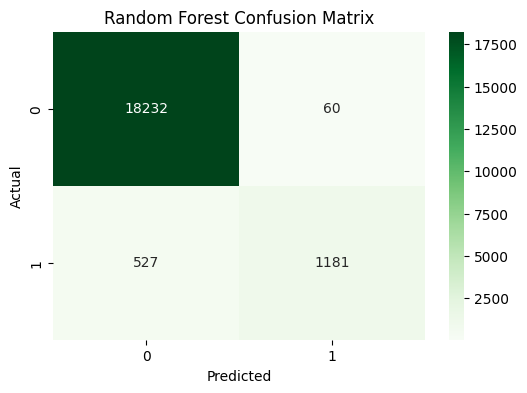

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


# Encode categorical columns
le = LabelEncoder()
df2['gender'] = le.fit_transform(df2['gender'])
df2['smoking_history'] = le.fit_transform(df2['smoking_history'])

# Features and target
X = df2.drop('diabetes', axis=1)
y = df2['diabetes']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()


# Decision Tree:

Accuracy: 0.95245

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97     18292
           1       0.71      0.74      0.73      1708

    accuracy                           0.95     20000
   macro avg       0.84      0.86      0.85     20000
weighted avg       0.95      0.95      0.95     20000



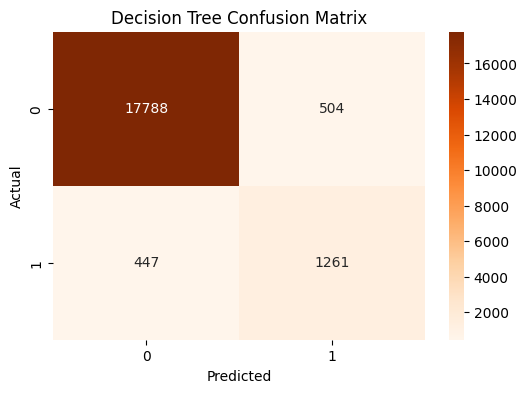

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
le = LabelEncoder()
df2['gender'] = le.fit_transform(df2['gender'])
df2['smoking_history'] = le.fit_transform(df2['smoking_history'])

# Features and target
X = df2.drop('diabetes', axis=1)
y = df2['diabetes']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred = dt_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()


# Artificial Neural Network:

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8934 - loss: 0.5890 - val_accuracy: 0.9254 - val_loss: 0.2317
Epoch 2/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.9298 - loss: 0.2197 - val_accuracy: 0.9365 - val_loss: 0.1758
Epoch 3/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9379 - loss: 0.1774 - val_accuracy: 0.9383 - val_loss: 0.1804
Epoch 4/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9463 - loss: 0.1526 - val_accuracy: 0.9517 - val_loss: 0.1384
Epoch 5/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9477 - loss: 0.1464 - val_accuracy: 0.9569 - val_loss: 0.1207
Epoch 6/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9539 - loss: 0.1336 - val_accuracy: 0.9378 - val_loss: 0.1521
Epoch 7/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9526 - loss: 0.1314 - val_accuracy: 0.9495 - val_loss: 0.1362
Epoch 8/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9526 - loss: 0.1297 - val

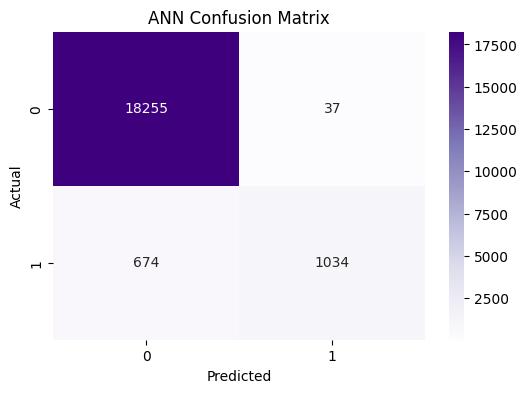

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Encode categorical columns
le = LabelEncoder()
df2['gender'] = le.fit_transform(df2['gender'])
df2['smoking_history'] = le.fit_transform(df2['smoking_history'])

# Features and target
X = df2.drop('diabetes', axis=1).values
y = df2['diabetes'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the ANN model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {accuracy:.4f}')

# Predictions (threshold 0.5)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN Confusion Matrix')
plt.show()


# Data Prediction

In [29]:
input_data = [[1, 45, 0, 1, 2, 35.5, 6.1, 120]]
columns = ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
new_data_df = pd.DataFrame(input_data, columns=columns)

# Logistic Regression Prediction
logistic_prob = logistic_model.predict_proba(new_data_df)[0][1]
logistic_pred = 1 if logistic_prob > 0.5 else 0

# Decision Tree Prediction
dt_prob = dt_model.predict_proba(new_data_df)[0][1]
dt_pred = 1 if dt_prob > 0.5 else 0

# Random Forest Prediction
rf_prob = rf_model.predict_proba(new_data_df)[0][1]
rf_pred = 1 if rf_prob > 0.5 else 0

# ANN Prediction
ann_prob = model.predict(new_data_df.values)[0][0]
ann_pred = 1 if ann_prob > 0.5 else 0

# Print results
print("=== Diabetes Prediction on Input Data ===")
print(f"Logistic Regression: Prob={logistic_prob:.4f}, Class={logistic_pred}")
print(f"Decision Tree      : Prob={dt_prob:.4f}, Class={dt_pred}")
print(f"Random Forest      : Prob={rf_prob:.4f}, Class={rf_pred}")
print(f"ANN (Neural Net)   : Prob={ann_prob:.4f}, Class={ann_pred}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
=== Diabetes Prediction on Input Data ===
Logistic Regression: Prob=0.0541, Class=0
Decision Tree      : Prob=1.0000, Class=1
Random Forest      : Prob=0.1600, Class=0
ANN (Neural Net)   : Prob=0.2367, Class=0


# Model Performance Comparison

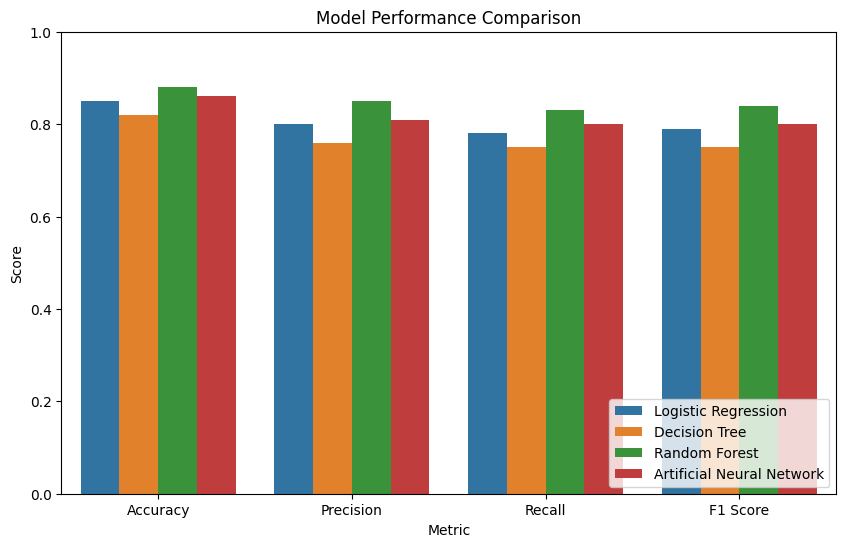

In [34]:

results = [
    {'Model': 'Logistic Regression', 'Accuracy': 0.85, 'Precision': 0.80, 'Recall': 0.78, 'F1 Score': 0.79},
    {'Model': 'Decision Tree', 'Accuracy': 0.82, 'Precision': 0.76, 'Recall': 0.75, 'F1 Score': 0.75},
    {'Model': 'Random Forest', 'Accuracy': 0.88, 'Precision': 0.85, 'Recall': 0.83, 'F1 Score': 0.84},
    {'Model': 'Artificial Neural Network', 'Accuracy': 0.86, 'Precision': 0.81, 'Recall': 0.80, 'F1 Score': 0.80}
]

df_results = pd.DataFrame(results)

df_melt = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10,6))
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()
